# Numeric interferometer usage

In [20]:
import numpy as np
from mwave.integrate import make_kvec, make_phi
from mwave.numeric import NumericBraggInterferometer
from mwave.precompute import load_precomputed_gbragg, get_bragg_precompute_info
from mwave.simulation_utils import cloud_init
from scipy.integrate import solve_ivp
import numpy as np
from numba import jit, float64

# Set interferometer parameters
omega_r_conversion = 2066*2*np.pi
nbragg = 4
T = 4.5e-3*omega_r_conversion
Tp = 8e-3*omega_r_conversion
    
# Initialize kvec and tree
ifr = NumericBraggInterferometer(-2*nbragg, 4*nbragg, distance=4) # Should pass in wavefunction initialization functions

ifr.split(nbragg) # Should pass in the relevant function here as well! Function will inspect input function arguments to ensure correct number and naming
ifr.propagate(T)
ifr.split(nbragg)
ifr.propagate(Tp)
ifr.split([3*nbragg, -nbragg])
ifr.propagate(T)
ifr.split([3*nbragg, -nbragg])

Plot the trajectories

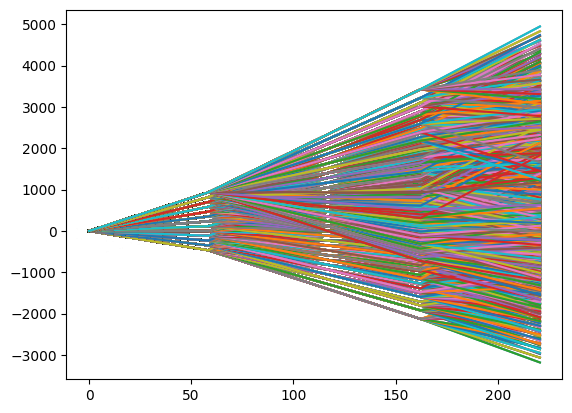

In [21]:
from matplotlib import pyplot as plt

nodes = ifr.get_nodes()
nA, nB, nC, nD = nodes[4*nbragg], nodes[2*nbragg], nodes[0.0*nbragg], nodes[-2*nbragg]
Ts = [0, 0, T, T, T + Tp, T + Tp, T + Tp + T, T + Tp + T]

plt.figure()
for nn in [nA, nB, nC, nD]:
    for p in nn:
        for node in nn[p]:
            t, x = node.get_trajectory()
            plt.plot(t, x)
plt.show()

Load precomputed `gbragg` function

In [3]:
_, grid, _ = get_bragg_precompute_info('../precomputation/gbragg_single_sig0.260.h5', 0, 0, 0)
for gdim in grid:
    print(f'{gdim[1]} dimension is {gdim[0].shape[0]}')

omegas dimension is 1200
deltas dimension is 1998


In [4]:
gbragg = load_precomputed_gbragg('../precomputation/gbragg_single_sig0.260.h5',
                                 '../precomputation/gbragg_multi_sig0.260.h5',
                                 table_sigma=0.259658916,
                                 table_modulation_frequency=8*4)

Loading single frequency Bragg precompute table, this could take a while...
Precompute table loaded! Performing checks...
Checks passed!
Loading multifrequency Bragg precompute table, this could take a while...
Precompute table loaded! Performing checks...
Checks passed!


Create function for simulation full interferometer

In [22]:
from numba import jit, float64
from mwave.integrate import bloch_rhs, omega_fnc_gaussian, phase_fnc_constant
from scipy.integrate import solve_ivp

Omega0 = 19.5
w0 = 6.2e-3

def deltalookup(vz):
    return 4*nbragg + 4*(vz/0.0035) # The modification to delta is 4 times the velocity defined in units of recoil velocities
        
def omegalookup(x, y, z):
    return Omega0*np.exp(-2*(x**2 + y**2)/(w0**2))

def cpops(x0, y0, z0, vz, vx, vy, cphase=0.0, injected_dphase=0.0):
    bs_lookup_dict = {}

    # Define beampslitter function
    def calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, z, idx):

        # Check if this is a multifrequency beamsplitter
        multifrequency = isinstance(klattice, list)

        # Load cached result
        if idx in bs_lookup_dict:
            if k_init in bs_lookup_dict[idx]:
                if int(k_final) in bs_lookup_dict[idx][k_init]:
                    return bs_lookup_dict[idx][k_init][int(k_final)]

        # Compute omegas and deltas
        x = x0 + vx*t
        y = y0 + vy*t
        omegas = omegalookup(x, y, z0 + z)
        deltas = deltalookup(vz)
        
        # Set sigma
        sigma = 0.259658916

        # Compute phases
        phases = deltas*t

        # Apply common mode phase if provided and at pulse 3
        if idx == 3:
            phases += cphase

            # Apply differential phase if provided at pulse 3. The way I am injecting this is unphysical/different from how we do in the experiment. But I'm not sure if there is a better way.
            if k_init == 0.0 and k_final == -2.0*nbragg:
                phases += injected_dphase

        # Compute effect of Bragg beamsplitter
        if not multifrequency:
            phi = gbragg(ifr.kvec, int(k_init), sigma, omegas, deltas, delta_phase=phases)
        else:
            phi = gbragg(ifr.kvec, int(k_init), sigma, omegas, deltas, delta_phase=phases, mod_freq=8*4, mod_phase=0.0)

        # Determine index of k_final state
        kf_idx = np.argmin(np.abs(ifr.kvec - k_final))

        # Save wavefunction to cache
        if idx not in bs_lookup_dict:
            bs_lookup_dict[idx] = {}
        if k_init not in bs_lookup_dict[idx]:
            bs_lookup_dict[idx][k_init] = {}
        if int(k_final) not in bs_lookup_dict[idx][k_init]:
            bs_lookup_dict[idx][k_init][int(k_final)] = phi[:,kf_idx]
        else:
            raise RuntimeError('Array should not have been created but it was!')

        # Return
        return phi[:,kf_idx]

    # Define free evolution function
    propfnc = lambda x0, y0, z0, vz, vx, vy, t, k: np.exp(-1j*t*k**2)

    # Apply functions to interferometer
    fnclst = [lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 1),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 2),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 3),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 4)]
    ifr.set_operation_funcs(fnclst)

    # Load population functions
    popfnc = ifr.get_population_func([4*nbragg, 2*nbragg, 0*nbragg, -2*nbragg], lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0), lambda x1, x2, x3, x4, x5, x6: np.ones_like(x0,dtype=np.complex128), lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0,dtype=np.complex128))

    # Evaluate populations and return
    return popfnc(4*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(2*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(0*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(-2*nbragg, [x0, y0, z0, vz, vx, vy])

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=3.5e-3, sigma_vertical_v=0.1*3.5e-3)
pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=np.pi/4)

Make ellipse

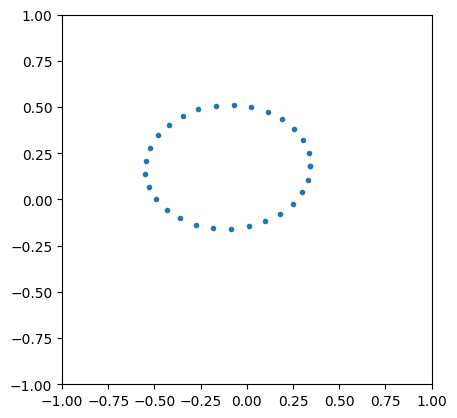

In [23]:
def calc_xy(a, b, c, d):
    return (a-b)/(a+b), (c-d)/(c+d)

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=0.1*3.5e-3/omega_r_conversion, sigma_vertical_v=0.1*3.5e-3)

cphases = np.linspace(0, 2*np.pi, 12)
x, y = np.full_like(cphases, np.nan), np.full_like(cphases, np.nan)
for i in range(len(cphases)):
    pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=cphases[i], injected_dphase=np.pi/8)
    x[i], y[i] = calc_xy(np.sum(pA), np.sum(pB), np.sum(pC), np.sum(pD))

plt.plot(x, y, '.')
plt.gca().set_aspect('equal')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()